# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [2]:
# Import pandas to be used for data manipulation and cleaning

import pandas as pd

# Load the dataset into a pandas DataFrame

df = pd.read_csv("openpowerlifting.csv")

# Preview the first few rows to confirm the data loaded correctly
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'openpowerlifting.csv'

## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [ ]:
# This tells us how many rows (observations) and columns (features) we are working with
df.shape

# Display basic information about the dataframe
df.info()


# View a list of all column names to identify which variables are relevant to the bench press analysis
df.columns


# Generate summary statistics for numerical columns which provides insight into ranges, averages, and potential outliers
df.describe()


# Check how many missing values exist in each column to know where to clean up
df.isna().sum().sort_values(ascending=False)


# Examine unique values for key categorical columns to verify expected categories

df["Sex"].value_counts(dropna=False)
df["Country"].value_counts().head(10)
df["Equipment"].value_counts()
df["Event"].value_counts()


# Confirm that bench press data exists and inspect its distribution numerically
# Best3BenchKg is the primary metric for this project
df["Best3BenchKg"].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1423354 entries, 0 to 1423353
Data columns (total 37 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Name             1423354 non-null  object 
 1   Sex              1423354 non-null  object 
 2   Event            1423354 non-null  object 
 3   Equipment        1423354 non-null  object 
 4   Age              757527 non-null   float64
 5   AgeClass         786800 non-null   object 
 6   Division         1415176 non-null  object 
 7   BodyweightKg     1406622 non-null  float64
 8   WeightClassKg    1410042 non-null  object 
 9   Squat1Kg         337580 non-null   float64
 10  Squat2Kg         333349 non-null   float64
 11  Squat3Kg         323842 non-null   float64
 12  Squat4Kg         3696 non-null     float64
 13  Best3SquatKg     1031450 non-null  float64
 14  Bench1Kg         499779 non-null   float64
 15  Bench2Kg         493486 non-null   float64
 16  Bench3Kg         4

count   1276181.00
mean        116.54
std          54.84
min        -522.50
25%          74.84
50%         111.13
75%         150.00
max         488.50
Name: Best3BenchKg, dtype: float64

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

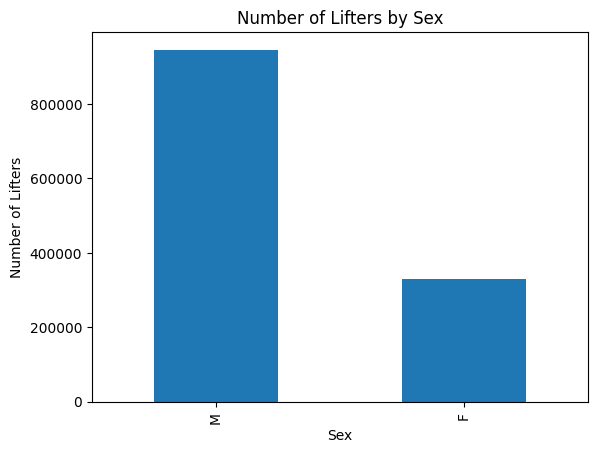

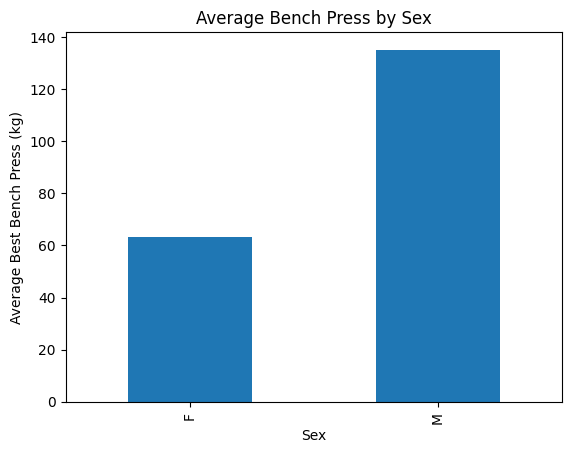

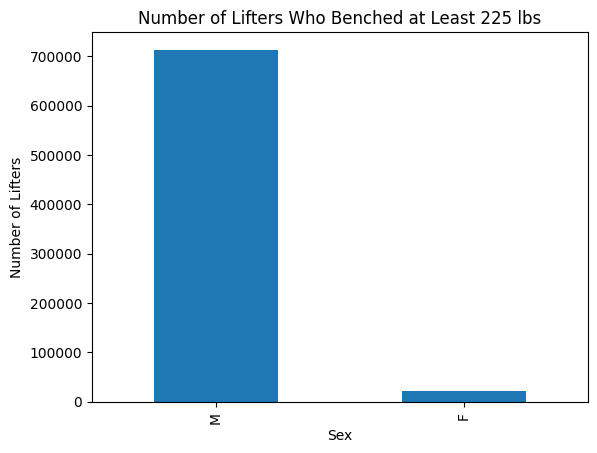

In [ ]:
# Filter to rows where bench press data exists
# This keeps the charts focused only on relevant records
bench_df = df[df["Best3BenchKg"].notna()]


# Visualization 1: Count of lifters by sex
# Get a simple count of how many men and women are in the dataset to see whether one group is much larger than the other

bench_df["Sex"].value_counts().plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Number of Lifters")
plt.title("Number of Lifters by Sex")
plt.show()


# Visualization 2: Average bench press by sex
# Compare the average bench press result between men and women that gives a simple high-level comparison before deeper analysis

bench_df.groupby("Sex")["Best3BenchKg"].mean().plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Average Best Bench Press (kg)")
plt.title("Average Bench Press by Sex")
plt.show()


# Visualization 3: Count of lifters who benched at least 225 lbs
# Get a simple count of lifters who meet or exceed the 225-lb benchmark
# 225 lbs is converted to kilograms for comparison

bench_225_lbs_to_kg = 102.06

bench_df[bench_df["Best3BenchKg"] >= bench_225_lbs_to_kg]["Sex"].value_counts().plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Number of Lifters")
plt.title("Number of Lifters Who Benched at Least 225 lbs")
plt.show()


## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
   - I noticed that there are some lifters with negative bench press values, which I didn’t expect.  
2. Do you have any concerns about your dataset? 
   - The dataset only includes competitive powerlifters, so it does not represent the general U.S. population.  
   - Some columns have missing values like age or bodyweight.  
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 
   - I will need to remove rows with negative bench press values and probably focus only on lifters from the USA.   
   - I should check for duplicates and make sure that all numerical columns are formatted correctly and consistent (integers/floats) before doing further analysis.

